# New Section

# Medical Insurance Project

## About the Data

## Load the Data

## Clean the Data

## Look at the Data

## Outliers

## Build Models

## Linear Regression

## Polynomial Regression

## Ridge Regression

## Tune Ridge Model

## Compare Models

## Final Thoughts

## About the Data

This dataset is about how much medical insurance costs.

The purpose of this project is to find out what makes insurance costs go up and to make models that can predict costs.

Link to the dataset: https://www.kaggle.com/datasets/mosapabdelghany/medical-insurance-cost-dataset

### Columns
- age: age of the person
- sex: male or female
- bmi: body mass index
- children: number of children
- smoker: yes or no
- region: where the person lives
- charges: insurance cost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import os

for root, dirs, files in os.walk("/"):
    if "data.csv" in files:
        print(os.path.join(root, "data.csv"))
        break

/usr/local/lib/python3.12/dist-packages/statsmodels/datasets/danish_data/data.csv


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("data.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

## Clean the Data

I looked through the dataset to see if there were any missing values, duplicate rows, or wrong data types.

There are 7 columns and 1338 rows in the dataset.

There were no missing values in any of the columns.

I took out one duplicate row from the dataset because it was there.

## Look at the Data

I used charts and summary statistics to help me understand the data set better.

I examined the distributions of the numerical columns, the dataset's categories, and the correlations among variables.

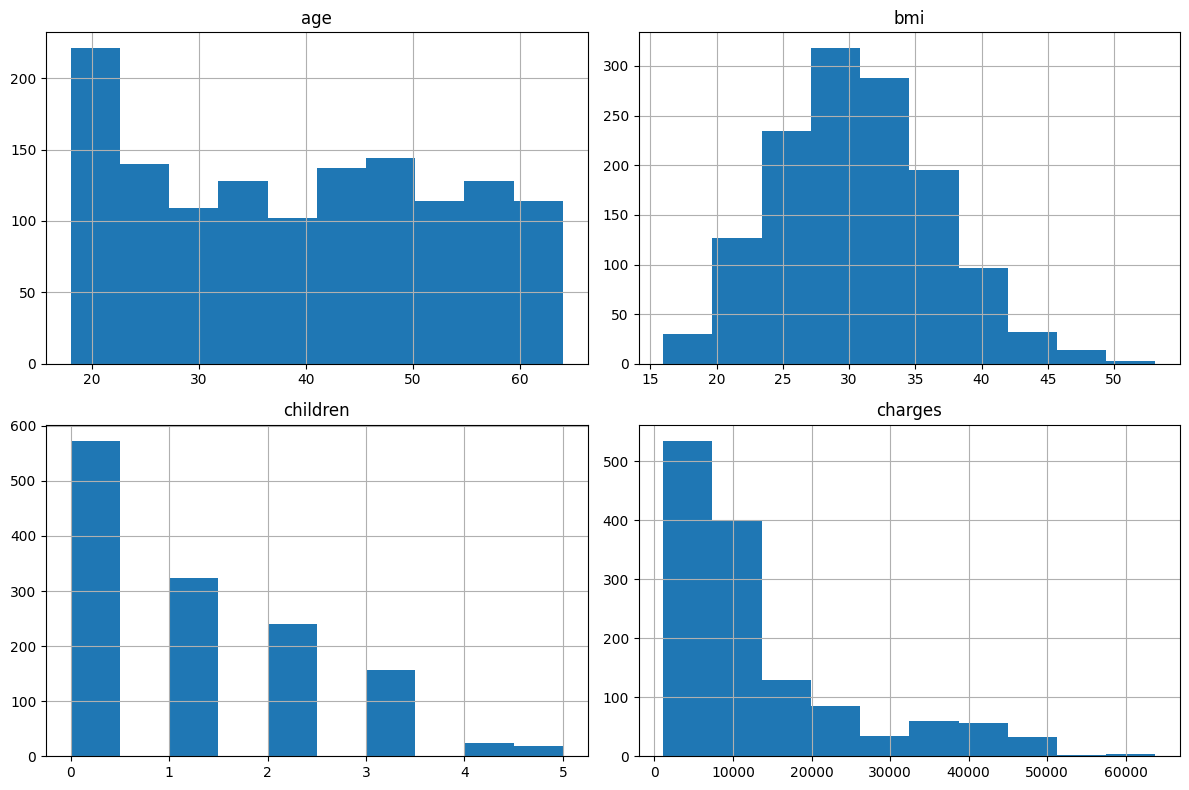

In [ ]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

The histograms show how the numbers in the columns are spread out.

It looks like the charges have some high values, but the age and BMI are more evenly spread out.

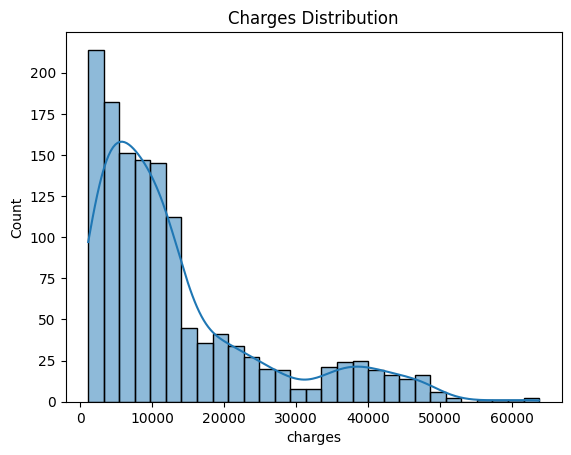

In [ ]:
sns.histplot(df["charges"], kde=True)
plt.title("Charges Distribution")
plt.show()

The charges distribution is right-skewed.

This means that most people have charges that are lower or middle, while a smaller group has charges that are very high.

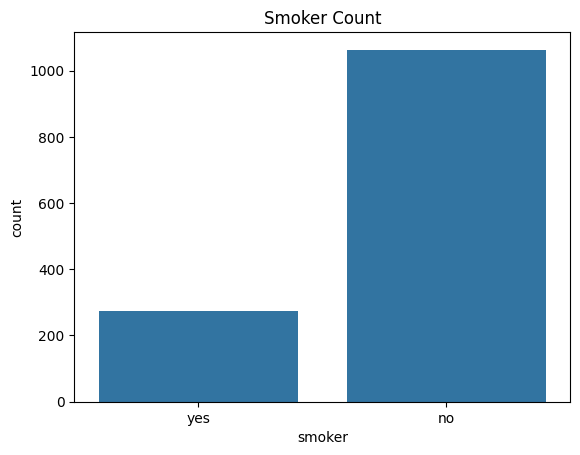

In [ ]:
sns.countplot(x="smoker", data=df)
plt.title("Smoker Count")
plt.show()

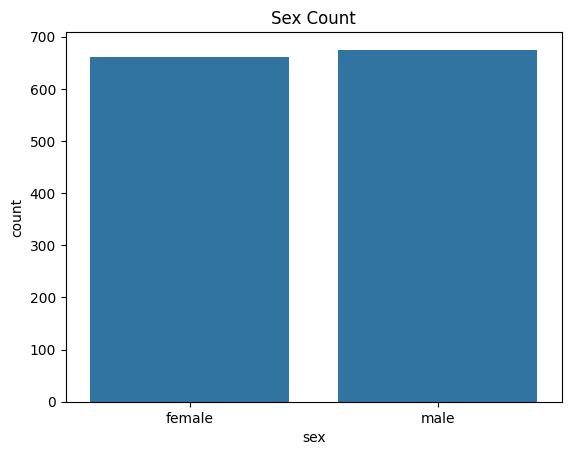

In [ ]:
sns.countplot(x="sex", data=df)
plt.title("Sex Count")
plt.show()

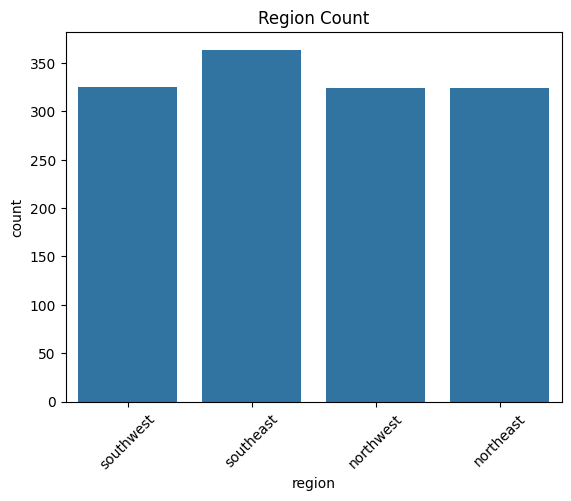

In [ ]:
sns.countplot(x="region", data=df)
plt.title("Region Count")
plt.xticks(rotation=45)
plt.show()

The dataset includes both smokers and non-smokers.

The counts for males and females look fairly balanced.

The regions also appear fairly balanced.

## Outliers

I looked for outliers using boxplots.

Values that are significantly higher or lower than the majority of the other data are known as outliers.

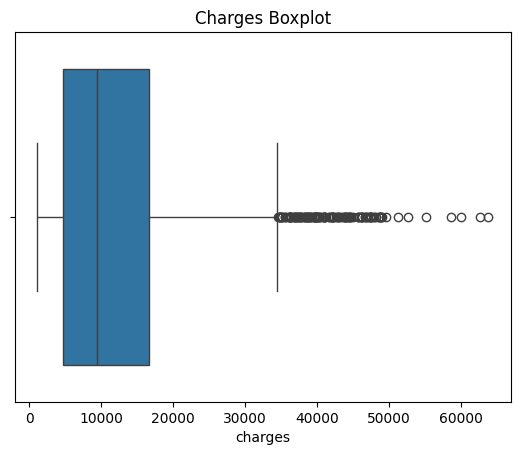

In [ ]:
sns.boxplot(x=df["charges"])
plt.title("Charges Boxplot")
plt.show()

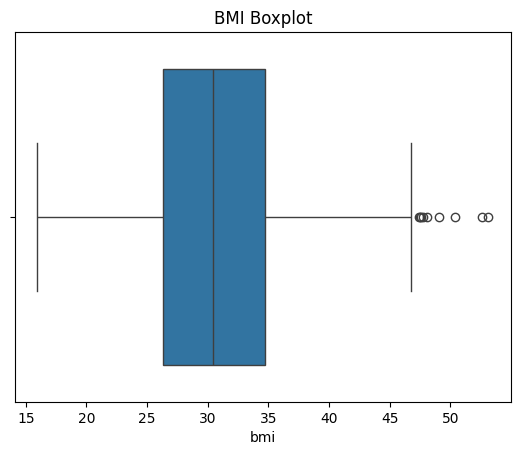

In [ ]:
sns.boxplot(x=df["bmi"])
plt.title("BMI Boxplot")
plt.show()

There are multiple high outliers in the charges column.

I kept these in the sample since they seemed plausible.

There are some potential outliers in the bmi column as well, but they might still be actual readings.

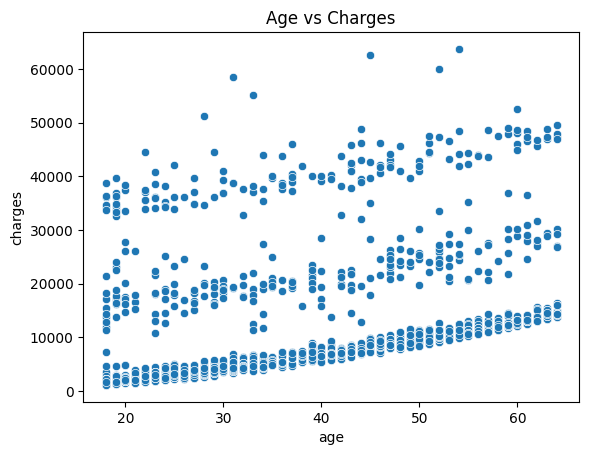

In [ ]:
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Charges")
plt.show()

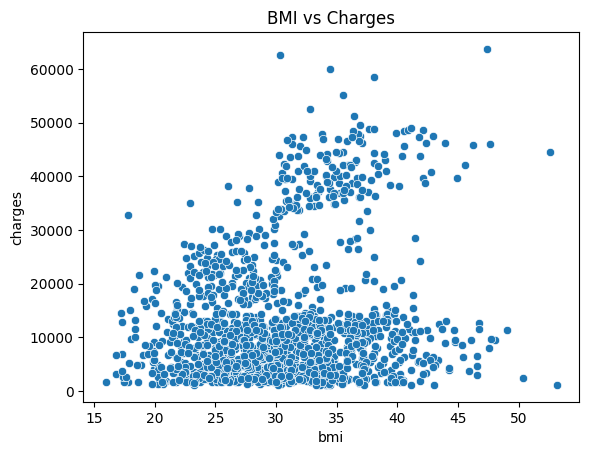

In [ ]:
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Charges")
plt.show()

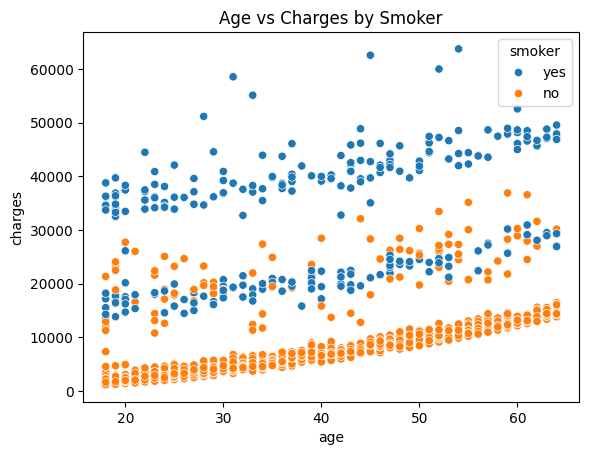

In [ ]:
sns.scatterplot(x="age", y="charges", hue="smoker", data=df)
plt.title("Age vs Charges by Smoker")
plt.show()

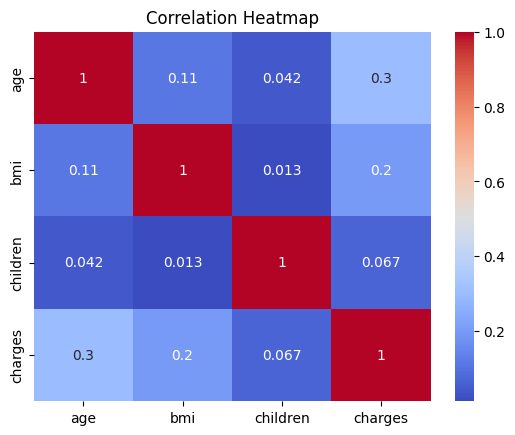

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Age and bmi seem to have some relationship with charges.

Smoker status appears to make a strong difference in charges.

The heatmap helps show which numeric columns are more related to each other.

In [ ]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [ ]:
categorical_features = X.select_dtypes(include=["object"]).columns
numeric_features = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

## Linear Regression

This model uses the variables in the dataset to predict charges.

I evaluated the model using MAE, RMSE, and R².

In [ ]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [ ]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = mse_linear ** 0.5
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression
MAE: 4177.045561036326
RMSE: 5956.342894363589
R²: 0.8069287081198011


In [ ]:
X_single = df[["age"]]
y_single = df["charges"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_single, y_single, test_size=0.2, random_state=42
)

single_linear = LinearRegression()
single_linear.fit(X_train_s, y_train_s)
y_pred_single = single_linear.predict(X_test_s)

mae_single = mean_absolute_error(y_test_s, y_pred_single)
mse_single = mean_squared_error(y_test_s, y_pred_single)
rmse_single = mse_single ** 0.5
r2_single = r2_score(y_test_s, y_pred_single)

print("Single-variable Linear Regression")
print("MAE:", mae_single)
print("RMSE:", rmse_single)
print("R²:", r2_single)

Single-variable Linear Regression
MAE: 9657.78934976123
RMSE: 12894.779883028823
R²: 0.09513000782072023


### Single-Variable Linear Regression (Age)

This model predicts insurance costs based only on age. Age alone may not account for most of the difference in charges, according to the model's low R2 score. This suggests that in order to increase prediction performance, more variables will probably be required.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_s)
X_test_poly = poly.transform(X_test_s)

single_poly = LinearRegression()
single_poly.fit(X_train_poly, y_train_s)

y_pred_poly_single = single_poly.predict(X_test_poly)

mae_poly_single = mean_absolute_error(y_test_s, y_pred_poly_single)
mse_poly_single = mean_squared_error(y_test_s, y_pred_poly_single)
rmse_poly_single = mse_poly_single ** 0.5
r2_poly_single = r2_score(y_test_s, y_pred_poly_single)

print("Single-variable Polynomial Regression")
print("MAE:", mae_poly_single)
print("RMSE:", rmse_poly_single)
print("R²:", r2_poly_single)

Single-variable Polynomial Regression
MAE: 9720.739486586126
RMSE: 12958.263747140814
R²: 0.08619832375759195


### Single-Variable Polynomial Regression (Age)

By including polynomial elements, this model introduces a curved link between age and charges. To determine whether permitting a nonlinear pattern enhances performance, it will be contrasted with the single-variable linear regression model.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

scaler_single = StandardScaler()

X_train_s_scaled = scaler_single.fit_transform(X_train_s)
X_test_s_scaled = scaler_single.transform(X_test_s)

single_ridge = Ridge(alpha=1.0)
single_ridge.fit(X_train_s_scaled, y_train_s)

y_pred_ridge_single = single_ridge.predict(X_test_s_scaled)

mae_ridge_single = mean_absolute_error(y_test_s, y_pred_ridge_single)
mse_ridge_single = mean_squared_error(y_test_s, y_pred_ridge_single)
rmse_ridge_single = mse_ridge_single ** 0.5
r2_ridge_single = r2_score(y_test_s, y_pred_ridge_single)

print("Single-variable Ridge Regression")
print("MAE:", mae_ridge_single)
print("RMSE:", rmse_ridge_single)
print("R²:", r2_ridge_single)

Single-variable Ridge Regression
MAE: 9657.887686928723
RMSE: 12895.039266962902
R²: 0.09509360377176956


### Single-Variable Ridge Regression (Age)

Ridge regularization is applied to the age predictor in this model. Although the effect may be minimal with just one predictor, ridge regression can assist stabilize coefficient estimates and lessen overfitting.

In [ ]:
single_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression"
    ],
    "MAE": [
        mae_single,
        mae_poly_single,
        mae_ridge_single
    ],
    "RMSE": [
        rmse_single,
        rmse_poly_single,
        rmse_ridge_single
    ],
    "R2": [
        r2_single,
        r2_poly_single,
        r2_ridge_single
    ]
})

single_results

,Model,MAE,RMSE,R2
0,Linear Regression,9657.789350,12894.779883,0.095130
1,Polynomial Regression,9720.739487,12958.263747,0.086198
2,Ridge Regression,9657.887687,12895.039267,0.095094


### Comparison of Single-Variable Models

MAE, RMSE, and R2 are used to compare the three single-variable models. It is anticipated that the performance of all three models will be limted because they only employ age as a variable.

In [ ]:
X_multi = df.drop("charges", axis=1)
y_multi = df["charges"]

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

multi_linear = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

multi_linear.fit(X_train_m, y_train_m)
y_pred_multi_linear = multi_linear.predict(X_test_m)

mae_multi_linear = mean_absolute_error(y_test_m, y_pred_multi_linear)
mse_multi_linear = mean_squared_error(y_test_m, y_pred_multi_linear)
rmse_multi_linear = mse_multi_linear ** 0.5
r2_multi_linear = r2_score(y_test_m, y_pred_multi_linear)

print("Multi-variable Linear Regression")
print("MAE:", mae_multi_linear)
print("RMSE:", rmse_multi_linear)
print("R²:", r2_multi_linear)

### Multi-variable Linear Regression

This model uses all the main columns to predict charges. It should work better than the age-only model because it has more information.

In [ ]:
# This makes the number columns more flexible by adding squared terms
numeric_transformer_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

# This still changes word columns into numbers
preprocessor_poly = ColumnTransformer([
    ("num", numeric_transformer_poly, numeric_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

# This builds the full polynomial model
multi_poly = Pipeline([
    ("preprocessor", preprocessor_poly),
    ("model", LinearRegression())
])

# Train the model
multi_poly.fit(X_train_m, y_train_m)

# Make predictions
y_pred_multi_poly = multi_poly.predict(X_test_m)

# Check how good the model is
mae_multi_poly = mean_absolute_error(y_test_m, y_pred_multi_poly)
mse_multi_poly = mean_squared_error(y_test_m, y_pred_multi_poly)
rmse_multi_poly = mse_multi_poly ** 0.5
r2_multi_poly = r2_score(y_test_m, y_pred_multi_poly)

print("Multi-variable Polynomial Regression")
print("MAE:", mae_multi_poly)
print("RMSE:", rmse_multi_poly)
print("R²:", r2_multi_poly)

Multi-variable Polynomial Regression
MAE: 4404.321296542795
RMSE: 6102.811232420253
R²: 0.7973165939697933


### Multi-variable Polynomial Regression

Similar to linear regression, this approach permits curved relationships. If fees do not rise in a straight line, that may be helpful.

In [ ]:
# This builds a ridge regression model
multi_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

# Train the model
multi_ridge.fit(X_train_m, y_train_m)

# Make predictions
y_pred_multi_ridge = multi_ridge.predict(X_test_m)

# Check how good the model is
mae_multi_ridge = mean_absolute_error(y_test_m, y_pred_multi_ridge)
mse_multi_ridge = mean_squared_error(y_test_m, y_pred_multi_ridge)
rmse_multi_ridge = mse_multi_ridge ** 0.5
r2_multi_ridge = r2_score(y_test_m, y_pred_multi_ridge)

print("Multi-variable Ridge Regression")
print("MAE:", mae_multi_ridge)
print("RMSE:", rmse_multi_ridge)
print("R²:", r2_multi_ridge)

Multi-variable Ridge Regression
MAE: 4193.891909470005
RMSE: 5971.861740959915
R²: 0.8059213292402461


### Multi-variable Ridge Regression

This model is similar to linear regression, but it adds regularization. That helps keep the model more controlled and can improve performance.

In [ ]:
from sklearn.model_selection import GridSearchCV

# These are the alpha values we want to test
param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

# This tests each alpha and finds the best one
grid_search = GridSearchCV(
    estimator=multi_ridge,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

# Run the search
grid_search.fit(X_train_m, y_train_m)

print("Best alpha:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best alpha: {'model__alpha': 1}
Best cross-validation score: 0.7258656187605561


In [ ]:
from sklearn.model_selection import GridSearchCV

# These are the alpha values we want to test
param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

# This tests each alpha and finds the best one
grid_search = GridSearchCV(
    estimator=multi_ridge,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

# Run the search
grid_search.fit(X_train_m, y_train_m)

print("Best alpha:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best alpha: {'model__alpha': 1}
Best cross-validation score: 0.7258656187605561


### Best Ridge Model

This shows how the best Ridge model performed after testing different alpha values.

In [ ]:
best_ridge_model = grid_search.best_estimator_

y_pred_best_ridge = best_ridge_model.predict(X_test_m)

mae_best_ridge = mean_absolute_error(y_test_m, y_pred_best_ridge)
mse_best_ridge = mean_squared_error(y_test_m, y_pred_best_ridge)
rmse_best_ridge = mse_best_ridge ** 0.5
r2_best_ridge = r2_score(y_test_m, y_pred_best_ridge)

print("Tuned Multi-variable Ridge Regression")
print("MAE:", mae_best_ridge)
print("RMSE:", rmse_best_ridge)
print("R²:", r2_best_ridge)

Tuned Multi-variable Ridge Regression
MAE: 4193.891909470005
RMSE: 5971.861740959915
R²: 0.8059213292402461


In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression (Tuned)"
    ],
    "Approach": [
        "Single-variable",
        "Single-variable",
        "Single-variable",
        "Multi-variable",
        "Multi-variable",
        "Multi-variable"
    ],
    "MAE": [
        mae_single,
        mae_poly_single,
        mae_ridge_single,
        mae_multi_linear,
        mae_multi_poly,
        mae_best_ridge
    ],
    "RMSE": [
        rmse_single,
        rmse_poly_single,
        rmse_ridge_single,
        rmse_multi_linear,
        rmse_multi_poly,
        rmse_best_ridge
    ],
    "R2": [
        r2_single,
        r2_poly_single,
        r2_ridge_single,
        r2_multi_linear,
        r2_multi_poly,
        r2_best_ridge
    ]
})

final_results

,Model,Approach,MAE,RMSE,R2
0,Linear Regression,Single-variable,9657.789350,12894.779883,0.095130
1,Polynomial Regression,Single-variable,9720.739487,12958.263747,0.086198
2,Ridge Regression,Single-variable,9657.887687,12895.039267,0.095094
3,Linear Regression,Multi-variable,4177.045561,5956.342894,0.806929
4,Polynomial Regression,Multi-variable,4404.321297,6102.811232,0.797317
5,Ridge Regression (Tuned),Multi-variable,4193.891909,5971.861741,0.805921


### Model Comparison

This table compares all the models and shows which one performed best.

### Results Summary

Because the single-variable models relied solely on age to predict insurance costs, they did badly. Their poor R2 values indicate that a large portion of the variation in charges cannot be explained by age alone.

Because the multi-variable models incorporated more data from the dataset—such as BMI, smoking status, sex, region, and number of children—they performed significantly better. With the lowest MAE and RMSE and the greatest R2, the multi-variable linear regression model was the best model overall. The polynomial regression model performed somewhat worse than the tuned Ridge Regression model.

## Conclusion

This experiment demonstrated that age was insufficient to accurately predict insurance costs. The multi-variable linear regression model produced the best overall results, and the multi-variable models all performed significantly better.

In [114]:
chat_text = """AI Chat Documentation

Chat link:
https://chatgpt.com/share/69b0f2ca-9228-8010-9818-268ad309639e

1. I used ChatGPT to help choose a dataset that would work well for a regression project with Linear Regression, Polynomial Regression, and Ridge Regression.

2. I used ChatGPT to help structure the notebook, including the introduction, dataset description, EDA, outlier analysis, modeling, and conclusion sections.

3. I used ChatGPT to help write and understand the code for single-variable and multi-variable regression models.

4. I used ChatGPT to help build and interpret Linear Regression, Polynomial Regression, and Ridge Regression models.

5. I used ChatGPT to help perform Ridge Regression hyperparameter tuning using GridSearchCV.

6. I used ChatGPT to help debug notebook errors and explain the final model results.
"""

with open("chat.txt", "w") as f:
    f.write(chat_text)

print("chat.txt created")

chat.txt created


In [ ]:
!ls

chat.txt  data.csv  sample_data
